In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# Clean column names (remove extra spaces)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()



In [16]:
# Convert date to datetime
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)

# Drop rows with missing values
df1 = df1.dropna()

# Rename columns for consistency
df1 = df1.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation'
})

print(df1.head())

           Region       Date Frequency  Unemployment_Rate    Employed  \
0  Andhra Pradesh 2019-05-31   Monthly               3.65  11999139.0   
1  Andhra Pradesh 2019-06-30   Monthly               3.05  11755881.0   
2  Andhra Pradesh 2019-07-31   Monthly               3.75  12086707.0   
3  Andhra Pradesh 2019-08-31   Monthly               3.32  12285693.0   
4  Andhra Pradesh 2019-09-30   Monthly               5.17  12256762.0   

   Labour_Participation   Area  
0                 43.24  Rural  
1                 42.05  Rural  
2                 43.50  Rural  
3                 43.97  Rural  
4                 44.68  Rural  


In [17]:
# Convert date to datetime
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

# Rename columns
df2 = df2.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation'
})

print(df2.head())

           Region       Date Frequency  Unemployment_Rate  Employed  \
0  Andhra Pradesh 2020-01-31         M               5.48  16635535   
1  Andhra Pradesh 2020-02-29         M               5.83  16545652   
2  Andhra Pradesh 2020-03-31         M               5.79  15881197   
3  Andhra Pradesh 2020-04-30         M              20.51  11336911   
4  Andhra Pradesh 2020-05-31         M              17.43  12988845   

   Labour_Participation Region.1  longitude  latitude  
0                 41.02    South    15.9129     79.74  
1                 40.90    South    15.9129     79.74  
2                 39.18    South    15.9129     79.74  
3                 33.10    South    15.9129     79.74  
4                 36.46    South    15.9129     79.74  


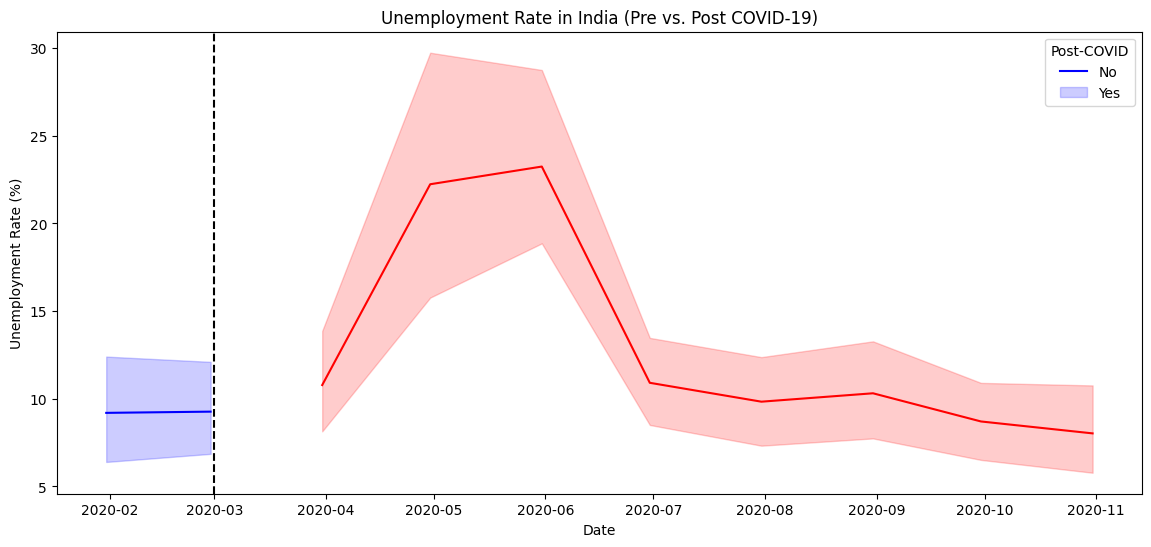

In [19]:
# Plot monthly unemployment rate (using df2 for cleaner data)
plt.figure(figsize=(14, 6))
sns.lineplot(
    x='Date',
    y='Unemployment_Rate',
    data=df2,
    hue=df2['Date'] > '2020-03-01',  # Highlight COVID period
    palette=['blue', 'red']
)
plt.axvline(x=pd.to_datetime('2020-03-01'), color='black', linestyle='--', label='COVID-19 Start')
plt.title("Unemployment Rate in India (Pre vs. Post COVID-19)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend(title='Post-COVID', labels=['No', 'Yes'])
plt.show()

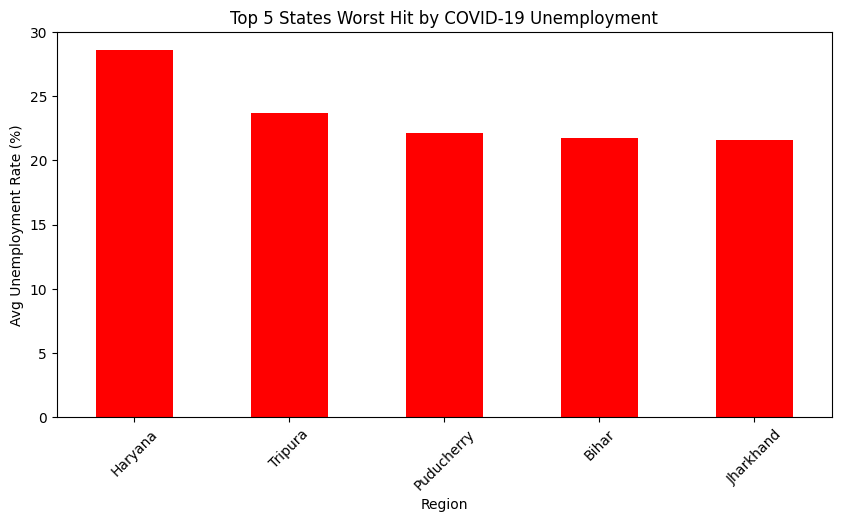

In [18]:
# Group by state and calculate avg unemployment during COVID
covid_period = df2[df2['Date'] >= '2020-03-01']
state_impact = covid_period.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(5)

# Bar plot
plt.figure(figsize=(10, 5))
state_impact.plot(kind='bar', color='red')
plt.title("Top 5 States Worst Hit by COVID-19 Unemployment")
plt.ylabel("Avg Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

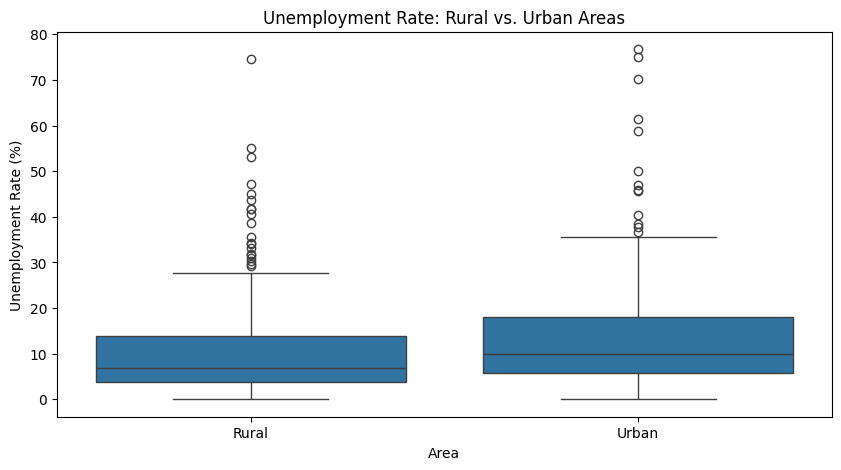

In [20]:
# Rural vs. Urban comparison
plt.figure(figsize=(10, 5))
sns.boxplot(x='Area', y='Unemployment_Rate', data=df1)
plt.title("Unemployment Rate: Rural vs. Urban Areas")
plt.xlabel("Area")
plt.ylabel("Unemployment Rate (%)")
plt.show()

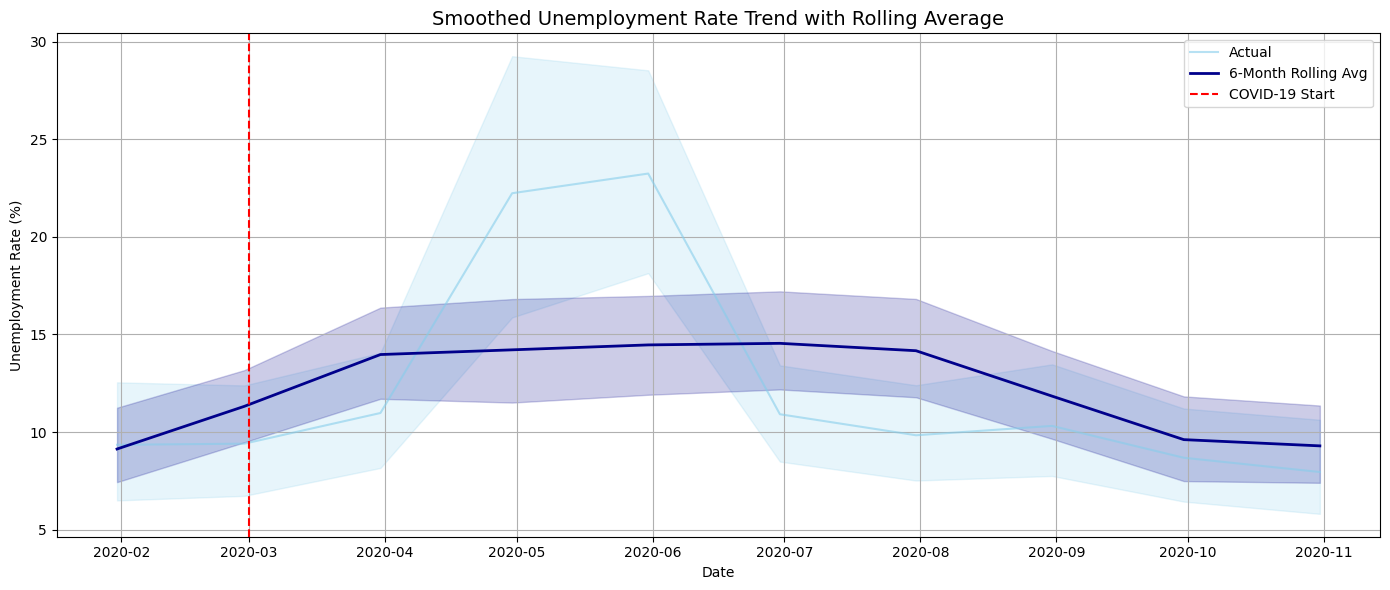

In [23]:
df2['Rolling_Avg'] = df2['Unemployment_Rate'].rolling(window=6, center=True).mean()
plot_df = df2.dropna(subset=['Rolling_Avg'])

plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Unemployment_Rate', data=plot_df, label='Actual', color='skyblue', alpha=0.6)
sns.lineplot(x='Date', y='Rolling_Avg', data=plot_df, label='6-Month Rolling Avg', color='darkblue', linewidth=2)
plt.axvline(x=pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='COVID-19 Start')
plt.title("Smoothed Unemployment Rate Trend with Rolling Average", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


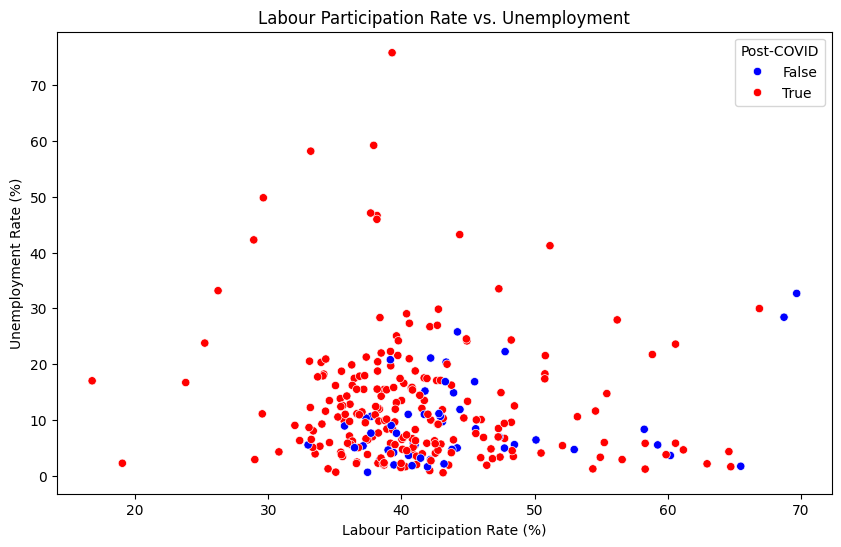

In [24]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Labour_Participation',
    y='Unemployment_Rate',
    data=df2,
    hue=df2['Date'] > '2020-03-01',
    palette=['blue', 'red']
)
plt.title("Labour Participation Rate vs. Unemployment")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.legend(title='Post-COVID')
plt.show()